# Part 4: Filtering + NUTS — A Marginal Sampler

Our motivation for using filters in the last tutorial was to do filter-based Bayesian inference of the parameters of a dynamical system -- but we didn't do that! In this tutorial, we will learn how to combine the filter-based marginal log-likelihood with `numpyro`'s inference infrastructure. 

The resulting inference methods are easily composable, which sometimes results in rather advanced methodology from simple code. In this tutorial, we will use a Taylor-extended Kalman filter over a linear Gaussian state-space model, which provides exact inference of the MLL. As a result, we are effectively performing MCMC on the marginalized posterior $p(\theta | y_{1:T})$, only. We'll conclude by talking about how composing different filters and inference algorithms can result in a flexible but powerful family of inference methods.

### Defining the Model

We again use the same LTI model as in the previous several tutorials.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    Condition,
    Context,
    DiscreteTimeSimulator,
    DynamicalModel,
    Trajectory,
)

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 2
observation_dim = 1
control_dim = 1

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))


def lti_model(sigma_obs=0.1, sigma_process=0.1):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5))
    A = jnp.array([[0, 0.3], [rho, -0.2]])

    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(
        A @ x + B @ u, sigma_process**2 * jnp.eye(state_dim)
    )

    # create the observation model as a callable mapping to a distribution
    observation_model = lambda x, u, t: dist.MultivariateNormal(
        C @ x, sigma_obs**2 * jnp.eye(observation_dim)
    )

    # create the dynamical model
    dynamics = DynamicalModel(
        state_dim=state_dim,
        observation_dim=observation_dim,
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    # sample from the dynamical model
    dsx.sample("f", dynamics)

### Generate synthetic data with $\rho = 0.3$.

We next generate synthetic data, using the predictive utilities discussed in tutorial 2.

In [2]:
# create a synthetic control sequence as i.i.d. Gaussians
obs_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
ctrl_times = obs_times  # same times for controls
ctrl_values = jr.normal(jr.PRNGKey(0), (len(ctrl_times), control_dim))
sim_context = Context(
    observations=Trajectory(times=obs_times),
    controls=Trajectory(times=obs_times, values=ctrl_values),
)

rho_true = 0.3


def make_data(sigma_obs=0.1, sigma_process=0.1):
    # create a time-conditioned model for data generation
    def time_conditioned_model():
        with DiscreteTimeSimulator():
            with Condition(sim_context):
                return lti_model(sigma_obs=sigma_obs, sigma_process=sigma_process)

    predictive = Predictive(
        time_conditioned_model,
        params={"rho": jnp.array(rho_true)},
        num_samples=1,
        exclude_deterministic=False,
    )
    pred = predictive(rng_key=jr.PRNGKey(0))
    # synthetic data object
    observed_context = Context(
        observations=Trajectory(times=obs_times, values=pred["observations"][0]),
        controls=Trajectory(times=obs_times, values=ctrl_values),
    )

    return observed_context


observed_context = make_data(sigma_obs=0.1, sigma_process=0.1)

### Running Marginalized MCMC

To run MCMC on the marginal distribution $p(\theta | y_{1:T})$ (marginalized from $p(\theta, x_{1:T} | y_{1:T})$), we must create a data-conditioned model by wrapping in a `FilterBasedMarginalLogLikelihood`. On this wrapped model, inference can proceed as any normal NumPyro model would. This works because `dynestyx` internally runs the appropriate filter to obtain a marginal likelihood estimate, then accounts for the marginal likelihood with a `numpyro.factor(...)` statement. Let's see this in action, and compare to the results of using a `DiscreteTimeSimulator`, as in the [previous tutorial](02_dynestyx_discrete_intro.ipynb).

In [3]:
from dynestyx import Filter
from numpyro.infer import MCMC, NUTS
from dynestyx.filters import EKFConfig
# Pseudo-marginal inference (record filtered states for latent recovery plot)
with Filter(EKFConfig()):
    with Condition(observed_context):
        nuts_kernel = NUTS(lti_model)
        mcmc = MCMC(nuts_kernel, num_warmup=100, num_samples=100)
        mcmc.run(jr.PRNGKey(1))
        posterior_1 = mcmc.get_samples()

# Joint state + parameter inference
with DiscreteTimeSimulator():
    with Condition(observed_context):
        nuts_kernel = NUTS(lti_model)
        mcmc = MCMC(nuts_kernel, num_warmup=100, num_samples=100)
        mcmc.run(jr.PRNGKey(1))
        posterior_2 = mcmc.get_samples()

sample: 100%|██████████| 200/200 [00:00<00:00, 282.57it/s, 31 steps of size 1.89e-01. acc. prob=0.89]


### Now let's compare the recovered posteriors over $\rho$

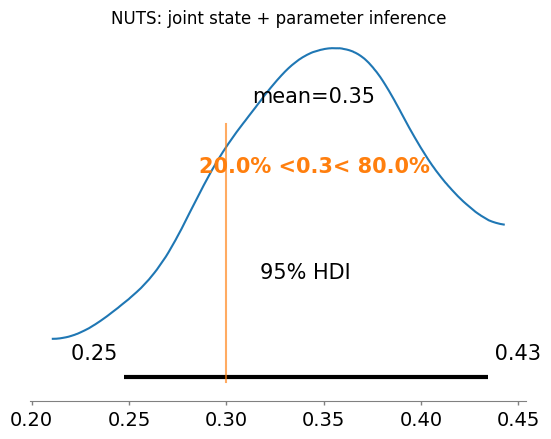

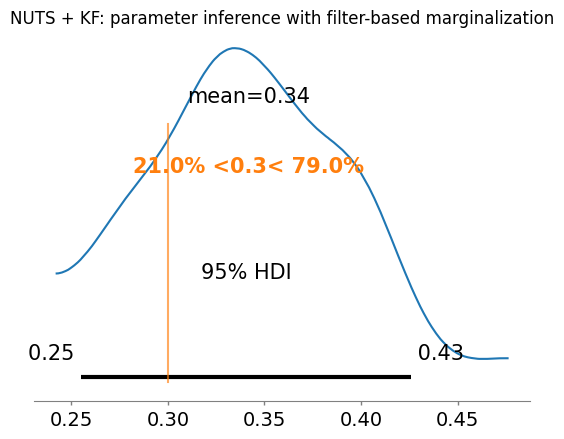

In [4]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_posterior(posterior_1["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.title("NUTS: joint state + parameter inference")

az.plot_posterior(posterior_2["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.title("NUTS + KF: parameter inference with filter-based marginalization")
plt.show()

### Next, let's compare latent-state recovery

In both cases, we can also recover the posterior distribution over latent states. In the "joint" case, it comes explicitly from the MCMC trace; this corresponds to a "smoothing" distribution. In the "marginal" case, we store the outputs of the filter (filtered state means and covariances) along with every sample of $\rho$; this corresponds to a "filtering" distribution.

What is "smoothing" and "filtering":
- The filtering distribution at time `t`: 
    - $p(x_t \mid y_1, \dots, y_t, u_1, \dots, u_t)$,
    - only uses data up to the present
- The smoothing distribution at time `t`: 
    - $p(x_t \mid y_1, \dots, y_T, u_1, \dots, u_T)$
    - uses all available data.


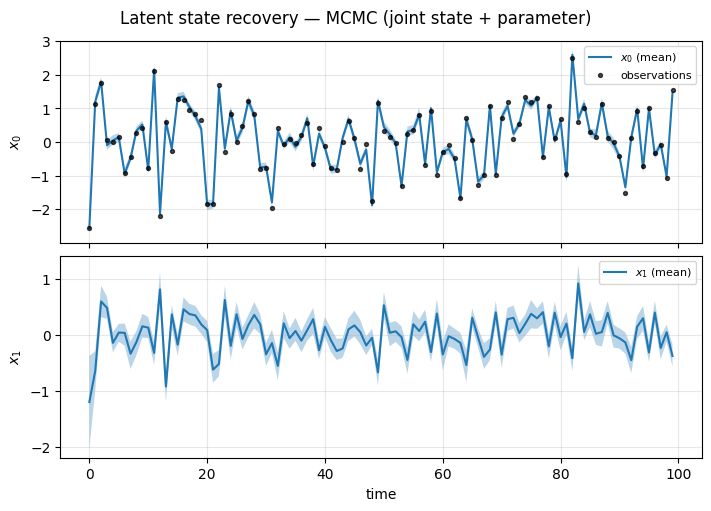

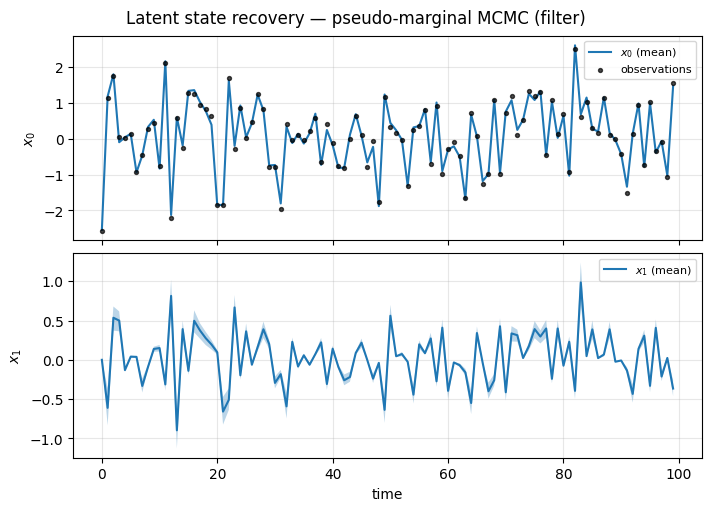

In [5]:
# Latent state recovery: 1 plot for MCMC (joint), 1 for marginal MCMC
# Observed component = first state (C = [1, 0]); overlay data as scatter there.
obs_times_np = jnp.asarray(observed_context.observations.times)
obs_values_np = jnp.asarray(observed_context.observations.values).squeeze()  # (T,)


def plot_latent_recovery(states_samples, title, obs_times, obs_values, state_dim=2):
    """states_samples: (num_samples, T, state_dim). One figure, one subplot per state component."""
    n_comp = state_dim
    mean_states = states_samples.mean(axis=0)  # (T, state_dim)
    lo = jnp.percentile(states_samples, 2.5, axis=0)
    hi = jnp.percentile(states_samples, 97.5, axis=0)
    fig, axes = plt.subplots(
        n_comp, 1, figsize=(7, 2.5 * n_comp), sharex=True, constrained_layout=True
    )
    if n_comp == 1:
        axes = [axes]
    for i in range(n_comp):
        ax = axes[i]
        ax.fill_between(obs_times_np, lo[:, i], hi[:, i], alpha=0.3)
        ax.plot(obs_times_np, mean_states[:, i], label=f"$x_{i}$ (mean)")
        if i == 0:  # observed component: overlay data
            ax.scatter(
                obs_times_np,
                obs_values_np,
                s=8,
                alpha=0.7,
                color="k",
                label="observations",
                zorder=3,
            )
        ax.set_ylabel(f"$x_{i}$")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("time")
    fig.suptitle(title)
    plt.show()


# MCMC (joint): posterior over states from simulator
plot_latent_recovery(
    posterior_2["states"],
    "Latent state recovery — MCMC (joint state + parameter)",
    obs_times_np,
    obs_values_np,
    state_dim=state_dim,
)

# Pseudo-marginal MCMC: filtered state means from KF (one per ρ sample)
plot_latent_recovery(
    posterior_1["f_filtered_states_mean"],
    "Latent state recovery — pseudo-marginal MCMC (filter)",
    obs_times_np,
    obs_values_np,
    state_dim=state_dim,
)

### Filtering was slower... so why bother?

In harder problems (e.g., non-linear, non-gaussian, etc.), sometimes joint MCMC over parameters + states doesn't work at all (it fails to even identify the region of highest probability)!
It's worth trying both approaches and comparing. Fortunately we make that easy; just swap `with FilterBasedMarginalLogLikelihood()` for `with DiscreteTimeSimulator()` and compare!

### Composing Different Inference Methods and Filters

The pattern we just used --- creating a data-conditioned model with a filter, then performing marginal inference with MCMC --- is easily generalized to other inference methods or filters. In fact, we recover lots of interesting filters from the literature this way! As a few examples:

- Using a particle filter with MCMC, we obtain [particle MCMC](https://academic.oup.com/jrsssb/article-abstract/72/3/269/7076437). This family of methods is known to be expensive but unbiased in a very wide range of scenarios, with applicability to nearly arbitrary state-space models. 
  - Depending on the inference method, we could be uncovering various different sub-methods; for example, using `HMC`, we obtain [particle Hamiltonian Monte Carlo](https://arxiv.org/abs/2504.09875). We can obtain the reduced-variance estimates therein by using a marginal particle filter.
- Using an ensemble Kalman filter (EnKF) as the filter, we obtain [ensemble MCMC](https://projecteuclid.org/journals/bayesian-analysis/volume-17/issue-1/Ensemble-MCMC--Accelerating-Pseudo-Marginal-MCMC-for-State-Space/10.1214/20-BA1251.full). This is biased but can be extremely fast.

In the coming tutorials, we will also step towards extremely simple implementations of variational sequential Monte Carlo methods by replacing the outer inference method with SVI!

**Next:** [Part 5 — SVI and warming up NUTS](../05_svi.ipynb)